<a href="https://colab.research.google.com/github/sendisha1808/netflix-eda-and-insights/blob/main/netflix_data_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [166]:
import pandas as pd
import matplotlib.pyplot as plt

In [167]:
# read csv file
df = pd.read_csv('netflix_titles.csv')
print(df.head())
print(df.shape)

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [168]:
#clean the data i,e dropping missing values
df = df.dropna(subset = ['type', 'release_year', 'rating','country', 'duration'])
print(df.shape)

(7970, 12)


# Bar Chart :- Movies vs TV Shows

type
Movie      5687
TV Show    2283
Name: count, dtype: int64


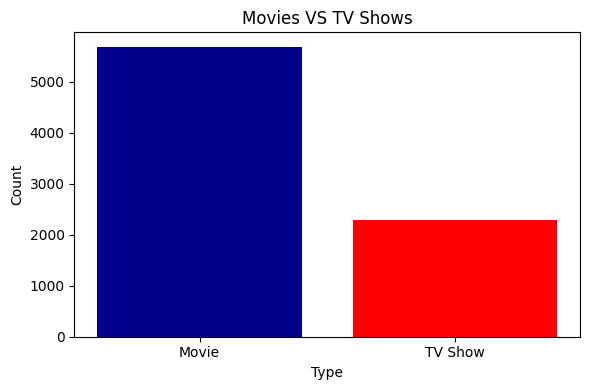

In [169]:
type_counts = df['type'].value_counts()
print(type_counts)

plt.figure(figsize = (6,4))
plt.bar(type_counts.index, type_counts.values, color = ['darkblue', 'red'])
plt.title('Movies VS TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('TV_vs_Mov.png', dpi = 300, bbox_inches = 'tight')
plt.show()

# Pie Chart:- Rating Counts

rating
TV-MA       2931
TV-14       1930
R            788
TV-PG        773
PG-13        482
PG           281
TV-Y7        236
TV-Y         227
TV-G         190
NR            80
G             41
TV-Y7-FV       5
NC-17          3
UR             3
Name: count, dtype: int64




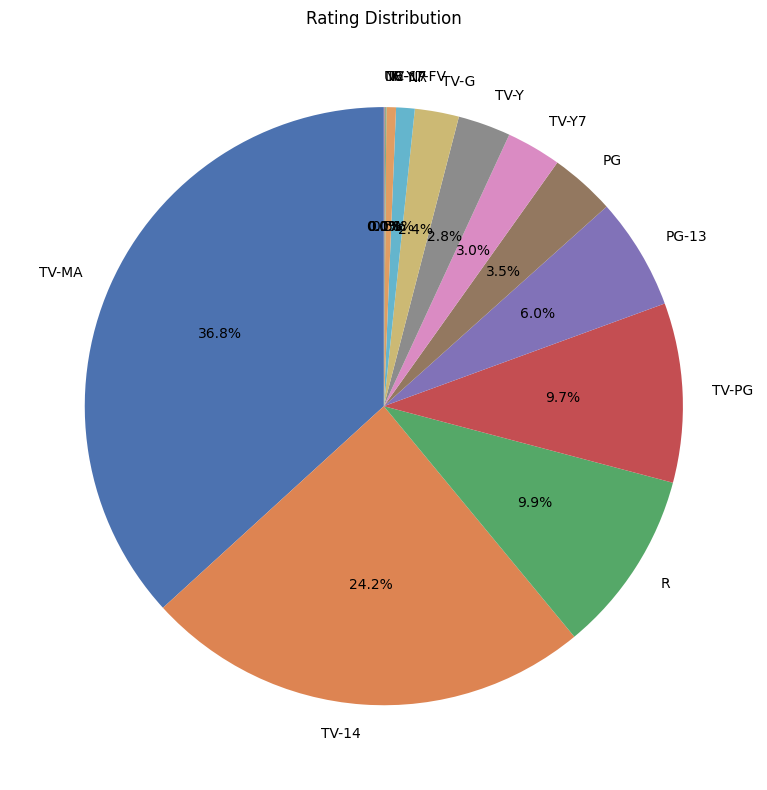

In [170]:
rating = df['rating'].value_counts()
print(rating)

print("\n")

plt.figure(figsize = (8, 8))
palette_14 = [
    "#4C72B0",
    "#DD8452",
    "#55A868",
    "#C44E52",
    "#8172B8",
    "#937860",
    "#DA8BC3",
    "#8C8C8C",
    "#CCB974",
    "#64B5CD",
    "#E19D62",
    "#71B190",
    "#8C6D31",
    "#B07AA1",
]
plt.pie(rating.values, labels = rating.index, colors = palette_14, autopct = '%1.1f%%', startangle = 90)
plt.title('Rating Distribution')
plt.tight_layout()
plt.savefig('Rating_Dist.png', dpi = 300, bbox_inches = 'tight')
plt.show()

# Histogram:- How much the duration of movies is distributed?

     show_id   type                 title             director  \
0         s1  Movie  Dick Johnson Is Dead      Kirsten Johnson   
7         s8  Movie               Sankofa         Haile Gerima   
9        s10  Movie          The Starling       Theodore Melfi   
12       s13  Movie          Je Suis Karl  Christian Schwochow   
24       s25  Movie                 Jeans           S. Shankar   
...      ...    ...                   ...                  ...   
8801   s8802  Movie               Zinzana      Majid Al Ansari   
8802   s8803  Movie                Zodiac        David Fincher   
8804   s8805  Movie            Zombieland      Ruben Fleischer   
8805   s8806  Movie                  Zoom         Peter Hewitt   
8806   s8807  Movie                Zubaan          Mozez Singh   

                                                   cast  \
0                                                   NaN   
7     Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...   
9     Melissa McCarthy, Chris 

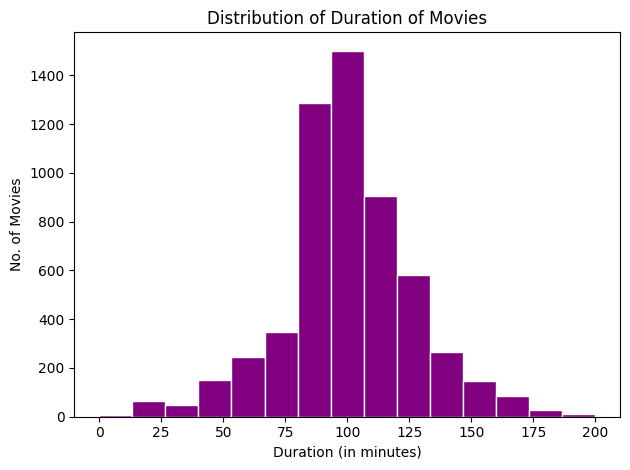

In [171]:
movies_df = df[df['type'] == 'Movie'].copy()
print(movies_df)

movies_df['duration_int'] = movies_df['duration'].str.replace(' min', '').astype(int)

plt.hist(movies_df['duration_int'], bins = 15, color = 'purple', edgecolor = 'white', range = (0, 200))

plt.xlabel('Duration (in minutes)')
plt.ylabel('No. of Movies')

plt.title('Distribution of Duration of Movies')
plt.tight_layout()
plt.savefig('Duration_Dist.png', dpi = 300, bbox_inches = 'tight')
plt.show()

# Scatter Plot :- Release Years vs Number of Shows

release_year
2018    1038
2017     965
2019     913
2020     852
2016     838
        ... 
1969       2
1961       1
1959       1
1966       1
1947       1
Name: count, Length: 73, dtype: int64





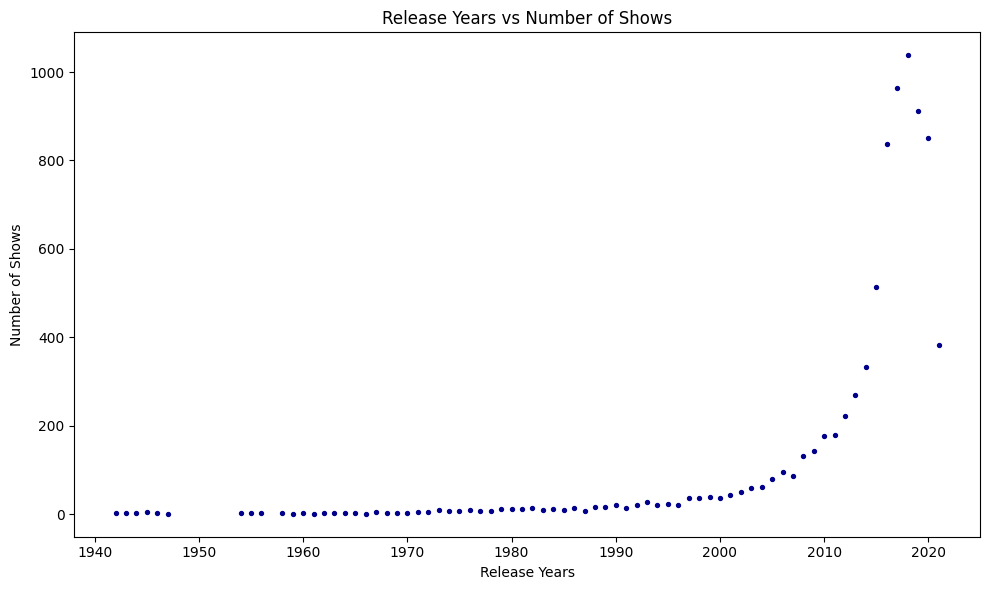

In [172]:
release_counts = df['release_year'].value_counts()
print(release_counts)

print('\n\n')

plt.figure(figsize = (10,6))
plt.scatter(release_counts.index, release_counts.values, color = 'darkblue', marker = 'o', s = 8)
plt.xlabel('Release Years')
plt.ylabel('Number of Shows')
plt.title('Release Years vs Number of Shows')
plt.tight_layout()
plt.savefig('Years_vs_No_of_shows', dpi = 300, bbox_inches = 'tight')
plt.show()

# Horizontal Barchart :- Representing the top 10 countries having most number of shows

country
United States     2815
India              972
United Kingdom     419
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


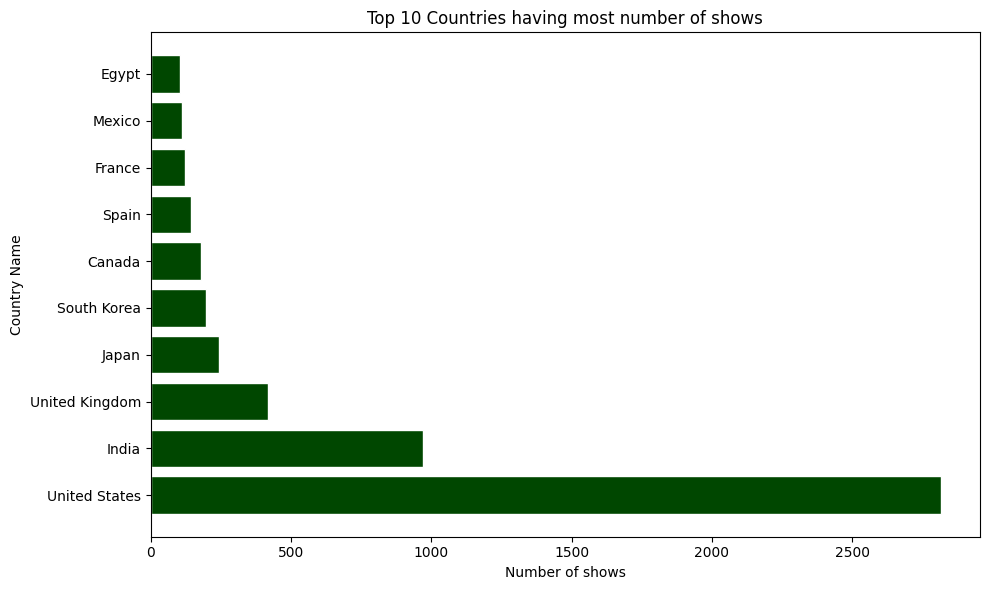

In [173]:
country_counts = df['country'].value_counts().head(10) # since top 10 countries
print(country_counts)

plt.figure(figsize = (10, 6))
plt.barh(country_counts.index, country_counts.values, color = '#004700', edgecolor = 'white')
plt.xlabel('Number of shows')
plt.ylabel('Country Name')
plt.title('Top 10 Countries having most number of shows')
plt.tight_layout()
plt.savefig('Top 10 Countries', dpi = 300, bbox_inches = 'tight')
plt.show()

#SubPlots :- Movies vs TV Shows per Year

type          Movie  TV Show
release_year                
1942            2.0      0.0
1943            3.0      0.0
1944            3.0      0.0
1945            3.0      1.0
1946            1.0      1.0
...             ...      ...
2017          729.0    236.0
2018          713.0    325.0
2019          565.0    348.0
2020          461.0    391.0
2021          169.0    214.0

[73 rows x 2 columns]



max y_limit =  729.0


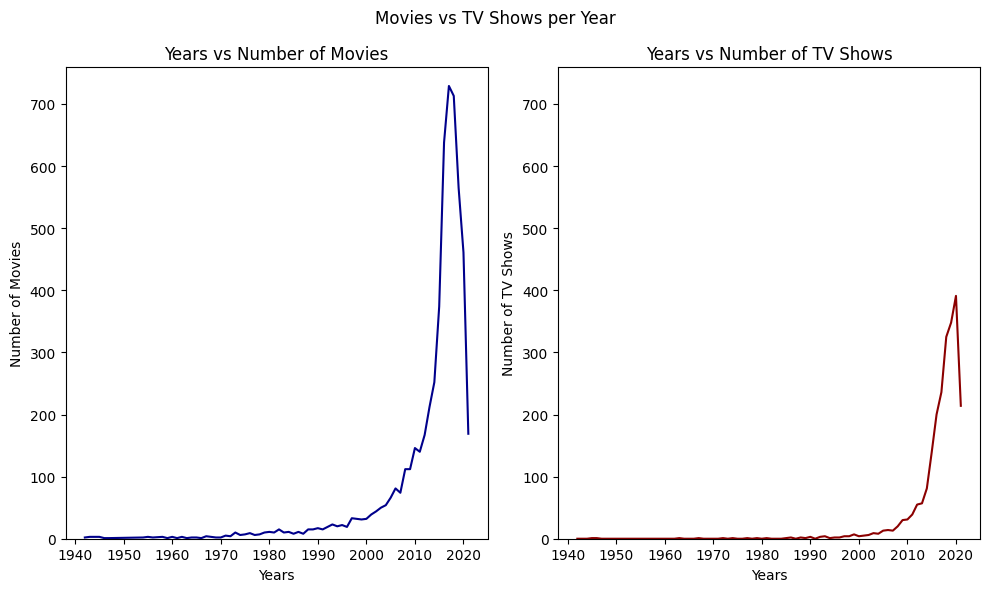

In [174]:
content_by_year = df.groupby(['release_year', 'type']).size().unstack().fillna(0)
print(content_by_year)

print('\n\n')

y_limit = content_by_year[['Movie','TV Show']].values.max()
print('max y_limit = ', y_limit)

fig, ax = plt.subplots(1, 2, figsize = (10, 6))

ax[0].plot(content_by_year.index, content_by_year['Movie'], color = 'darkblue')
ax[0].set_title('Years vs Number of Movies')
ax[0].set_xlabel('Years')
ax[0].set_ylabel('Number of Movies')
ax[0].set_ylim(0, y_limit+30)

ax[1].plot(content_by_year.index, content_by_year['TV Show'], color = 'darkred')
ax[1].set_title('Years vs Number of TV Shows')
ax[1].set_xlabel('Years')
ax[1].set_ylabel('Number of TV Shows')
ax[1].set_ylim(0, y_limit+30)

plt.suptitle('Movies vs TV Shows per Year')
plt.tight_layout()
plt.savefig('Movies_vs_TV Shows_per_Year.png', dpi = 300, bbox_inches = 'tight')
plt.show()